<div align="center">

# Assignment 3 - Transformers and Attention

</div>

**Course:** Advanced Data Mining  
**Deadline:** 23.03.2026 7:00 (SKOS), 16-24.03.2026 (presentation)

---

## General remark

Your solution should take the form of a short report (e.g. in Overleaf, HackMD, etc.).

The implementation code for **Task 3** should be provided as a `.py` file or a **Jupyter Notebook**.

---

# Task 1: Properties of the Attention Matrix [1 point]

Consider the self-attention mechanism defined as

$$
A = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)
$$

where the softmax function is applied **row-wise**.  
The matrices $Q, K \in \mathbb{R}^{n \times d_k}$ represent **queries** and **keys** respectively.

### Questions

1. Show that every element of the attention matrix $A$ is **strictly positive**.

2. Prove that the **sum of elements in each row of $A$** is equal to **1**.

3. Provide a **probabilistic interpretation** of the element $A_{ij}$ in the context of the attention mechanism.

### Hint

Recall that for a vector $z \in \mathbb{R}^n$ the softmax function is defined as

$$
\text{softmax}(z)_i =
\frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}
$$

---



# Task 2: Linear Structure of Sinusoidal Positional Encoding [2 points]

In the original Transformer architecture, sinusoidal positional encodings are defined as

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)
$$

$$
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)
$$

where:

- $pos$ denotes the **position in the sequence**
- $i$ indexes the **embedding dimension**

### Questions

1. Consider two positions $p$ and $q$ in the sequence. Write explicitly the positional encoding vectors $PE(p)$ and $PE(q)$ for a single pair of coordinates $(2i, 2i+1)$.

2. Show that the positional encoding at position $p$ can be expressed as a **linear transformation** of the positional encoding at position $q$ that depends only on the offset

$$
\Delta = p - q
$$

3. Conclude that there exists a matrix $M_{\Delta}$ such that

$$
PE(p) = M_{\Delta} PE(q)
$$

Finally, discuss **why this property may be useful for modeling relative token positions in Transformer architectures**.

---

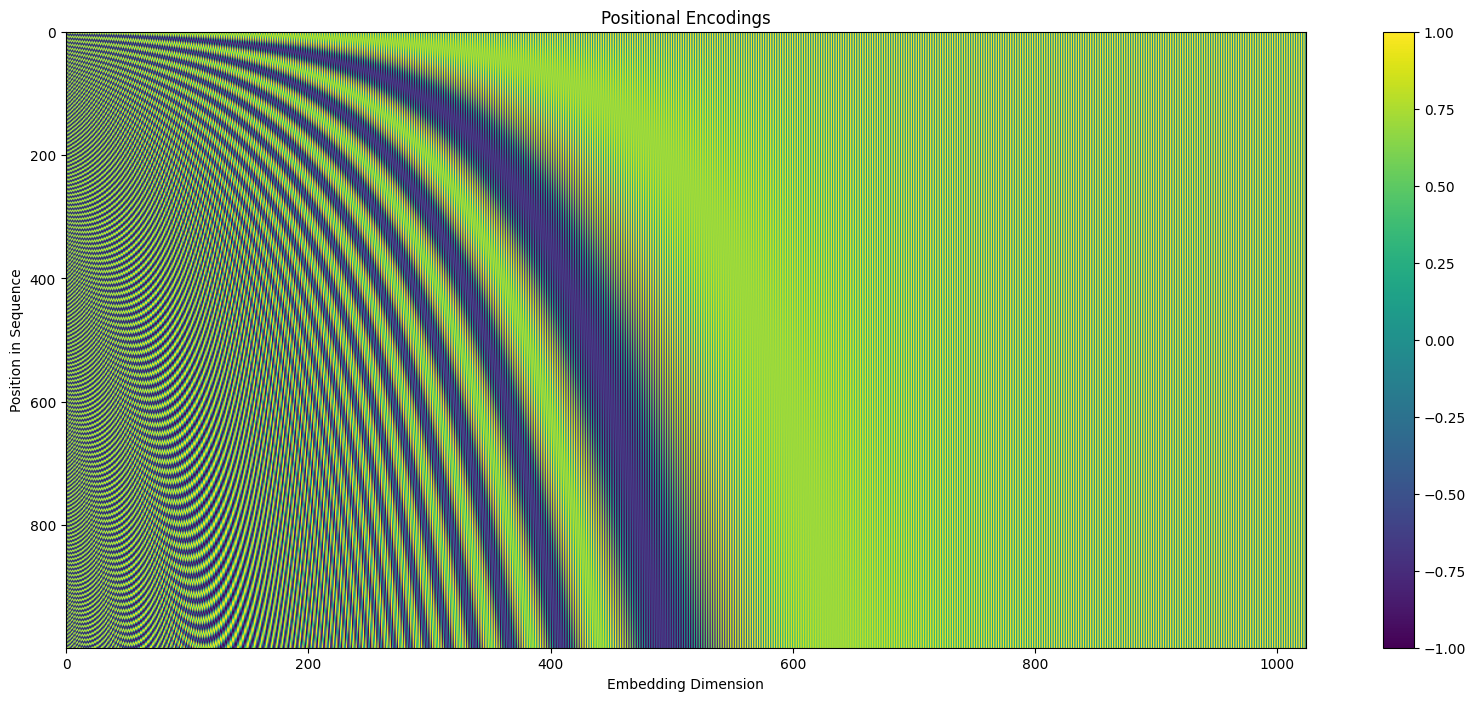

In [18]:
import numpy as np

import matplotlib.pyplot as plt

def get_positional_encodings(seq_len, d, n=10**5):
    positional_encodings = np.zeros(shape=(seq_len, d))

    for pos in range(seq_len):
        for i in range(d // 2):
            angle_arg = pos / np.power(n, 2 * i / d)
            positional_encodings[pos, 2 * i] = np.sin(angle_arg)
            positional_encodings[pos, 2 * i + 1] = np.cos(angle_arg)

    return positional_encodings

sequence_len = 1000 # Number of tokens
d_model = 1024 # Embedding dimensions

positional_encodings = get_positional_encodings(sequence_len, d_model)

plt.figure(figsize=(20, 8))
plt.imshow(positional_encodings, cmap='viridis', aspect='auto')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position in Sequence')
plt.title('Positional Encodings')
plt.colorbar()
plt.show()



# Task 3: Implementing a Transformer [2 points]

Using the tutorials below, implement and train a **Transformer model**.

### Tutorials

- Building a Transformer from Scratch - Part 1
- Building a Transformer from Scratch - Part 2

During the **lab session** you will be asked two questions about your implementation.

### Grading

- **1 point** - correct implementation and successful execution of the code
- **1 point** - correct answer to the questions
